___
# Week 5, notebook 2: Predictive modelling

> **Directions:**
> 
> * Step 1. Click **"Run all"** at the top to execute the whole notebook.
>
> * Step 2. Go down the page following directions below. 
>
> * Do not re-run the cells. If unsure, click on the little downward pointing arrow next to "Run all" and select "Restart session".
>
> Enjoy!

## Key learning:

After working through this notebook you will be familiar with:

* The structure of the dataset
* Different types of variables contained in the dataset
* Descriptive statistics
* Number of missing values
* Number of outliers
* Types of encoding for categorical variables

## Import libraries

Here, we import open-source libraries that we will use for data transformation.
* `pandas` is a powerful and flexible framework for working with datasets
* `ipywidgets` enables interactive visualisations
* `utils` is out custom script that provides some additional functions

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from ipywidgets import (
    Dropdown,
    Button,
    Layout,
    Output,
    GridspecLayout,
    Label, 
    FloatSlider, 
    HBox,
    Checkbox,
    VBox,
    interact,
)

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Pretty plots
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.title_fontsize'] = 12
plt.rcParams['legend.fontsize'] = 12

from utils import get_categorical_features_encoded, name2model, checkbox2feature, score_cv, evaluate, select_features_cv

# Set display options and button color
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
button_color = 'lightblue'

## Load data

Data for type 2 diabetes patients has been pre-selected and saved in a separate file. 
* `parquet` files allow storing large amounts of data and associated metadata and quickly loading them in Jupyter notebooks. 
* The dataset contains patient demographics​, vitals​, edical history, including history and family history of diabetes​, problem list​, current medications​, lab results​, number of previous admissions.
* All data is synthetic and does not contain any real patient data.

In [2]:
# Load the prepared dataset with only T2DM patients
dataset = pd.read_parquet("../data/t2dm_synthetic_T2DM_only_prepared.parquet", engine="pyarrow")

### Split the data

Just like we did in the previous notebook but here we will use the 80:20 split ration for the *development* vs. *holdout* sets.


In [3]:
# Split data
dev_dataset, holdout_dataset = train_test_split(dataset, train_size=0.8, random_state=42, stratify=dataset.outcome_admission_in_2025)

# Define feature names
cols_to_exclude = ['patient_id', 'outcome_admission_in_2025']
categorical_features = dev_dataset.drop(cols_to_exclude, axis=1).select_dtypes(include='category').columns.tolist()
numeric_features = dev_dataset.drop(cols_to_exclude, axis=1).select_dtypes(exclude='category').columns.tolist()

# Features and labels
X_dev = dev_dataset.drop(columns=cols_to_exclude)
y_dev = dev_dataset.outcome_admission_in_2025
X_holdout = holdout_dataset.drop(columns=cols_to_exclude)
y_holdout = holdout_dataset.outcome_admission_in_2025

print("After splitting the data, the development dataset has {} rows and {} columns, the holdout dataset has {} rows and {} columns.".format(dev_dataset.shape[0], dev_dataset.shape[1], holdout_dataset.shape[0], holdout_dataset.shape[1]))
dev_dataset.head(10)

After splitting the data, the development dataset has 3061 rows and 76 columns, the holdout dataset has 766 rows and 76 columns.


,patient_id,hospital,age,sex,height,weight,weight_over_100,bmi,waist,obesity,interpreter,alcohol,smoker,systolic_bp,diastolic_bp,elevated_bp,years_since_diagnosis,gestational_diabetes,family_history,siblings,children,hypertension,hyperlipidaemia,ischemic_heart_disease,cardiac_failure,neuropathy,nephropathy,sympt_peripheral_neuropathy,depression,stroke,acute_myocardial_infarction,transient_ischemic_attack,cabg,cardiomyopathy,autonomic_neuropathy,retinopathy,lower_limb_problems,charcot_foot,ulceration,claudication,nephropathy_indication,cardiovascular_disease,cerebrovascular_disease,oral_contraceptive,beta_blockers,ace_inhibitor,calcium_channel_blocker,corticosteroids,thaizide,agr2_receptor_blocker,aspirin,method_manage_t2dm,sodium,potassium,chloride,bicarbonate,creatinine,urea,haemoglobin,albumin,white_cell_count,platelets,red_cell_count,packed_cell_volume,mean_cell_volume,hba1c,egfr,islet_antibody,coeliac_antibody,thyroid_function,thyroid_antibody,vitamin_b12,dka_diagnosis,admissions_in_2024,visits_before_2025,outcome_admission_in_2025
748,816377,RMH,59,M,158.0,83.9,False,33.603221,79.8,True,False,False,CURRENT,125.0,80.1,False,28,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,DIET ONLY,139.0,4.6,106.9,24.4,73.2,12.4,109.6,35.0,10.5,243.0,4.2,0.3,82.4,8.9,NaN,False,False,False,False,False,False,0,7,False
1435,421757,RMH,75,M,160.0,97.3,False,38.008909,81.0,True,False,False,NO,136.7,76.0,False,4,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,TABLETS,140.0,4.5,104.2,24.1,196.1,25.2,112.0,NaN,10.0,238.0,2.5,0.2,95.1,8.2,NaN,False,False,False,False,False,False,0,36,True
1648,960767,RMH,71,M,173.0,97.9,False,32.706432,84.0,True,False,False,UNKNOWN,110.0,70.1,False,12,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,False,True,BOTH INSULIN AND TABS,137.0,3.8,103.9,23.4,80.2,9.4,138.0,36.0,9.0,143.0,5.7,0.4,94.7,6.9,NaN,False,False,False,False,False,False,0,38,False
74,915817,RMH,35,F,172.0,101.4,True,34.270917,92.3,True,False,False,NO,130.0,75.1,False,12,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,UNKNOWN,136.0,4.3,103.9,24.0,74.2,15.9,127.6,38.0,6.8,439.0,4.5,0.4,87.9,9.8,NaN,False,False,False,False,False,False,0,18,False
395,904071,RMH,55,M,157.0,104.3,True,42.318784,91.9,True,False,False,NO,197.8,69.2,True,12,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,NON-INSULIN,135.0,4.4,103.2,20.8,108.0,17.4,93.9,21.3,9.5,478.0,2.5,0.2,97.7,11.5,NaN,False,False,False,False,False,False,2,21,True
258,504593,WH,47,M,165.0,93.6,False,34.375419,83.8,True,False,False,NO,NaN,NaN,False,12,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,INSULIN,140.0,4.4,101.9,25.0,89.2,5.6,163.8,41.0,8.3,299.0,5.1,0.4,86.0,8.3,NaN,False,False,False,False,False,False,0,2,False
230,649558,RMH,46,M,166.0,65.9,False,23.910249,70.3,False,False,False,UNKNOWN,NaN,NaN,False,14,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,UNKNOWN,139.0,3.7,103.9,23.7,64.2,2.0,157.2,35.0,5.9,243.0,4.3,0.4,83.2,7.5,NaN,False,False,False,False,F

## Data preprocessing

Let's quickly apply all the transformations we covered in the previous notebook.

In [4]:
# Define transformers for numeric and categorical features. Adding StandardScaler to standardise numeric variables.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')), 
        ("encoder", OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='median')), 
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features),
        ("numeric", numeric_transformer, numeric_features)
    ]
)

# Fit the preprocessor
preprocessor.fit(X_dev)
categorical_features_encoded = get_categorical_features_encoded(preprocessor)

# Transform the development set
X_dev_transformed = pd.DataFrame(preprocessor.transform(X_dev), index=X_dev.index, columns=categorical_features_encoded + numeric_features)
X_dev_transformed.head()

,hospital RMH,hospital WH,sex F,sex M,smoker CURRENT,smoker FORMER,smoker NO,method UNKNOWN,method BOTH INSULIN AND TABS,method DIET ONLY,method INSULIN,method INSULIN AND NON-INSULIN,method NON-INSULIN,method OTHER,method TABLETS,method UNKNOWN,age,height,weight,weight_over_100,bmi,waist,obesity,interpreter,alcohol,systolic_bp,diastolic_bp,elevated_bp,years_since_diagnosis,gestational_diabetes,family_history,siblings,children,hypertension,hyperlipidaemia,ischemic_heart_disease,cardiac_failure,neuropathy,nephropathy,sympt_peripheral_neuropathy,depression,stroke,acute_myocardial_infarction,transient_ischemic_attack,cabg,cardiomyopathy,autonomic_neuropathy,retinopathy,lower_limb_problems,charcot_foot,ulceration,claudication,nephropathy_indication,cardiovascular_disease,cerebrovascular_disease,oral_contraceptive,beta_blockers,ace_inhibitor,calcium_channel_blocker,corticosteroids,thaizide,agr2_receptor_blocker,aspirin,sodium,potassium,chloride,bicarbonate,creatinine,urea,haemoglobin,albumin,white_cell_count,platelets,red_cell_count,packed_cell_volume,mean_cell_volume,hba1c,egfr,islet_antibody,coeliac_antibody,thyroid_function,thyroid_antibody,vitamin_b12,dka_diagnosis,admissions_in_2024,visits_before_2025
748,0.314805,-0.314805,-0.922315,0.922315,2.500711,-0.449753,-0.592316,-0.875969,-0.438153,3.451900,-0.475259,-0.269314,-0.222184,-0.134008,-0.680583,-0.383799,-0.888665,-1.125397,-0.191755,-0.568170,0.172544,-0.208712,1.04307,-0.311661,-0.24098,-0.478761,0.663811,-0.683668,0.973655,-0.127547,-0.632166,-0.351145,-0.126218,-0.732562,-0.695013,1.780534,-0.470086,-0.518214,-0.278276,-0.15186,-0.180903,-0.234848,-0.310398,-0.102784,-0.321034,-0.260843,-0.040449,-0.072488,-0.266512,0.0,-0.284362,-0.218106,-0.018078,-0.447126,-0.253625,-0.070175,-0.362778,-0.507544,-0.344654,-0.126218,-0.255081,-0.341681,-0.458650,0.058280,0.502039,1.018041,-0.290098,-0.789888,0.276219,-0.669230,0.089233,0.096517,-0.054447,0.158414,-0.884757,-0.947955,0.358825,-0.003276,-0.110614,-0.062735,-0.221373,-0.060055,-0.107547,0.0,-0.412940,-0.565967
1435,0.314805,-0.314805,-0.922315,0.922315,-0.399886,-0.449753,1.688287,-0.875969,-0.438153,-0.289696,-0.475259,-0.269314,-0.222184,-0.134008,1.469329,-0.383799,0.268130,-0.900860,0.276967,-0.568170,0.607648,-0.100466,1.04307,-0.311661,-0.24098,0.243039,0.222558,-0.683668,-1.260706,-0.127547,-0.632166,2.847827,-0.126218,1.365073,-0.695013,-0.561629,2.127268,-0.518214,-0.278276,-0.15186,-0.180903,-0.234848,-0.310398,-0.102784,-0.321034,-0.260843,-0.040449,-0.072488,3.752175,0.0,-0.284362,-0.218106,-0.018078,-0.447126,-0.253625,-0.070175,-0.362778,-0.507544,-0.344654,7.922805,-0.255081,-0.341681,-0.458650,0.397433,0.285322,0.253574,-0.388577,1.722828,2.611618,-0.545532,0.089233,0.068929,-0.118676,-1.879006,-2.234828,1.261830,-0.099072,-0.003276,-0.110614,-0.062735,-0.221373,-0.060055,-0.107547,0.0,-0.412940,1.739691
1648,0.314805,-0.314805,-0.922315,0.922315,-0.399886,-0.449753,-0.592316,1.141593,2.282307,-0.289696,-0.475259,-0.269314,-0.222184,-0.134008,-0.680583,-0.383799,-0.021069,0.558627,0.297955,-0.568170,0.083978,0.170149,1.04307,-0.311661,-0.24098,-1.404146,-0.412415,-0.683668,-0.515919,-0.127547,-0.632166,-0.351145,-0.126218,-0.732562,1.438823,1.780534,2.127268,-0.518214,-0.278276,-0.15186,-0.180903,-0.234848,-0.310398,-0.102784,-0.321034,-0.260843,-0.040449,-0.072488,-0.266512,0.0,-0.284362,-0.218106,-0.018078,-0.447126,-0.253625,-0.070175,2.756504,1.970274,-0.344654,-0.126218,3.920330,-0.341681,2.180312,-0.620027,-1.231699,0.168633,-0.618362,-0.646772,-0.271140,0.794537,0.269704,0.013752,-1.339028,1.956138,0.465313,1.192230,-0.949451,-0.003276,-0.110614,-0.062735,-0.221373,-0.060055,-0.107547,0.0,-0.412940,1.898702
74,0.314805,-0.314805,1.084228,-1.084228,-0.399886,-0.449753,1.688287,-0.875969,-0.438153,-0.289696,-0.475259,-0.269314,-0.222184,-0.134008,-0.680583,2.605533,-2.623857,0.446359,0.420383,1.760035,0.238486,0.918849,1.04307,-0.311661,-0.24098,-0.170300,0.125698,-0.683668,-0.515919,-0.127547,1.581

## Train a machine learning model

Now you can select features and algorithms to create the model. Experiment with this tool, try to find the best combination of the features.

**Directions:**
* Build your readmissions model: As a team, decide upon 5-10 features you want to use to train a model.
* Click the checkbox next to those features.
* Choose the algorithm you would like to experiment with.
* Click the button `“Start training"`.
* Try to get the best score with the smallest number of features!

**Available algorithms:**
- Support Vector Machines
- Logistic Regression
- k Nearest Neighbours
- Decision Tree

In [5]:
# Feature selection checkboxes (Cross-validation only)
def _build_checkbox_grid(feature_names, n_cols=4):
    master = Checkbox(value=False, description='All')

    cbs = [Checkbox(value=False, description=fn) for fn in sorted(feature_names)]

    def on_master_change(change):
        for cb in cbs:
            cb.value = change['new']

    master.observe(on_master_change, names='value')

    rows = []
    # First row includes master toggle + first (n_cols-1) features
    first = [master] + cbs[:max(0, n_cols-1)]
    rows.append(HBox(children=tuple(first)))

    # Remaining rows
    start = max(0, n_cols-1)
    for i in range(start, len(cbs), n_cols):
        rows.append(HBox(children=tuple(cbs[i:i+n_cols])))

    return rows

checkboxes = []
checkboxes = _build_checkbox_grid(X_dev_transformed.columns, n_cols=4)
display(VBox(children=tuple(checkboxes)))

In [ ]:
list_of_models = Dropdown(description ='Algorithm:', 
                          options = ['Support Vector Machines', 'Logistic Regression', 'k Nearest Neighbours', 'Decision Tree'], 
                          value = 'Support Vector Machines')
button = Button(description ="Start training", layout=Layout(width='50%'))
button.style.button_color = button_color
output = Output()

def on_button_clicked(_):
    output.clear_output()
    with output:
        model = name2model(list_of_models.value)
        if len(checkboxes) > 0:
            feature_list = checkbox2feature(checkboxes)
            if 'All' in feature_list:
                feature_list.remove('All')
        else:
            print('Chose at least one feature')
        score_cv(model, X_dev_transformed[feature_list], y_dev)

button.on_click(on_button_clicked)
display(list_of_models, button)
display(output)

Dropdown(description='Algorithm:', options=('Support Vector Machines', 'Logistic Regression', 'k Nearest Neigh…

Button(description='Start training', layout=Layout(width='50%'), style=ButtonStyle(button_color='lightblue'))

Output()

## Evaluate the final model

Once you are happy with your final model, it is time to evaluate it on unseen data. Fingers crossed it works!
* As a team, decide on the probability threshold:
    * How many unnecessary readmission are you willing to tolerate to make sure you flag everyone who is at high risk?
    * How many high-risk patients are you willing to miss to make sure you do not flag everyone, and create an alert fatigue or worry the patients unnecessarily?
* Click the button `"Evaluate on unseen data"`

* What happens next?
    * Your selected model is re-trained on the full development dataset
    * We next predict the probability of readmission for each patient in the *holdout* set
    * You can examine the ROC and Precision-Recall curves to see how the model performs at different threshold values
    * Finally, your selected threshold is used to covert predicted probabilities into predictions. The confusion matrix helps you see how many patients got misclassified. 

Button(description='Test on the holdout set', layout=Layout(width='50%'), style=ButtonStyle(button_color='ligh…

Output()

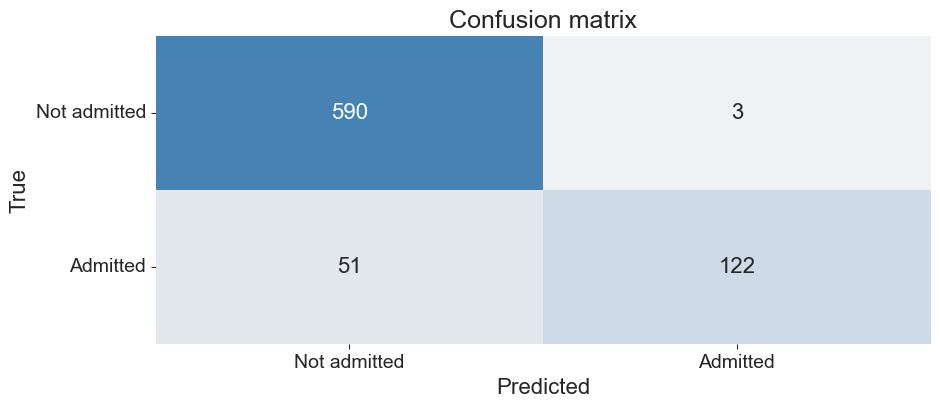

In [ ]:
# Transform the holdout set
X_holdout_transformed = pd.DataFrame(preprocessor.transform(X_holdout), index=X_holdout.index, columns=categorical_features_encoded + numeric_features)
X_holdout_transformed.head()

button2 = Button(description ="Evaluate on unseen data", layout=Layout(width='50%'))
button2.style.button_color = button_color
output2 = Output()
label = Label("Set a probability threshold:")
threshold = FloatSlider(value=0.5, min=0, max=1, step=0.05)

def on_button_clicked2(_):
    output2.clear_output()
    model = name2model(list_of_models.value)
    with output2:
        evaluate(model, X_dev_transformed, y_dev, X_holdout_transformed, y_holdout, threshold=threshold.value)

button2.on_click(on_button_clicked2)
display(HBox([label, threshold]))
display(button2)
display(output2)

In [ ]:
# sfs = []
# # Sequential feature selection
# for clf in clfs:
#     sfs.append(select_features_cv(clf, X_dev_transformed, y_dev, tol=0.001))
    
# feature_names = categorical_features_encoded + numeric_features
# # Default cross-validation
# for i, clf in enumerate(clfs):
#     score_cv(clf, X_dev_transformed.loc[:, sfs[i].get_support()], y_dev)
#     print("Using % d features:" % sum(sfs[i].get_support()))
#     print(np.asarray(feature_names)[sfs[i].get_support()])
#     print()

# for i, clf in enumerate(clfs):
#     # All features
#     clf.fit(X_dev_transformed, y_dev)
#     y_proba = clf.predict_proba(X_holdout_transformed)
#     score = roc_auc_score(y_holdout, y_proba[:, 1])
#     print(f"{clf.__class__.__name__} - ROC AUC on holdout: {score:.4f}")
#     print()
#     # Selected features
#     fts = np.asarray(feature_names)[sfs[i].get_support()]
#     clf.fit(X_dev_transformed.loc[:, fts], y_dev)
#     y_proba_selected = clf.predict_proba(X_holdout_transformed.loc[:, fts])
#     score_selected = roc_auc_score(y_holdout, y_proba_selected[:, 1])
#     print(f"{clf.__class__.__name__} - ROC AUC on holdout (Selected Features): {score_selected:.4f}")
#     print()